# Cointegration & Vector Error Correction Models

Topic 17 of the Time Series Analysis repo. Topic 08 (VAR) modeled several stationary series jointly. But most real macro and financial series (GDP, prices, exchange rates, stock levels) are **non-stationary** — I(1) — and differencing them to force stationarity, as VAR requires, throws away any long-run equilibrium relationship between them. Cointegration theory asks: can two or more non-stationary series still move together in the long run, so that some linear combination of them *is* stationary? If so, a **Vector Error Correction Model (VECM)** can exploit that relationship for better short-run forecasts. This notebook builds the theory from the ground up: why naive regression on non-stationary levels is dangerous (spurious regression), how to test for cointegration (Engle-Granger, Johansen), how a VECM is estimated, and what happens when it is applied to real macroeconomic data — including an honest case where two standard cointegration tests disagree.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
from scipy import stats as spstats
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.tsa.api import VAR

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

## 1. The Danger: Spurious Regression

Two **independent** random walks, with no relationship whatsoever, are regressed on each other. If OLS assumptions held, the slope should be statistically indistinguishable from zero about 95% of the time. Because both series are non-stationary, this is false: OLS on levels of I(1) series produces "significant" relationships far more often than it should. This is the classic Granger & Newbold (1974) result and the entire reason cointegration theory exists.

In [2]:
n = 500
x = np.cumsum(np.random.normal(0, 1, n))
y = np.cumsum(np.random.normal(0, 1, n))

model = sm.OLS(y, sm.add_constant(x)).fit()
print("Spurious regression: y = a + b*x, where x and y are INDEPENDENT random walks")
print(f"  slope={model.params[1]:.4f}   t-stat={model.tvalues[1]:.4f}   p-value={model.pvalues[1]:.2e}   R^2={model.rsquared:.4f}")
print("  -> a textbook 'highly significant' relationship between two series that share nothing but non-stationarity")

resid_adf = adfuller(model.resid)
print(f"\nADF test on the regression residuals: stat={resid_adf[0]:.4f}, p-value={resid_adf[1]:.4f}")
print("  -> residuals are NON-stationary: the tell-tale sign this regression is spurious, not genuine")

n_trials = 200
false_positives = 0
for _ in range(n_trials):
    xx = np.cumsum(np.random.normal(0, 1, n))
    yy = np.cumsum(np.random.normal(0, 1, n))
    m = sm.OLS(yy, sm.add_constant(xx)).fit()
    if m.pvalues[1] < 0.05:
        false_positives += 1
print(f"\nAcross {n_trials} independent random-walk pairs, a 'significant' (p<0.05) OLS regression appeared "
      f"{false_positives}/{n_trials} = {false_positives/n_trials:.1%} of the time (should be ~5% under correct inference).")

Spurious regression: y = a + b*x, where x and y are INDEPENDENT random walks
  slope=1.1213   t-stat=21.0471   p-value=8.02e-71   R^2=0.4708
  -> a textbook 'highly significant' relationship between two series that share nothing but non-stationarity

ADF test on the regression residuals: stat=-1.7426, p-value=0.4093
  -> residuals are NON-stationary: the tell-tale sign this regression is spurious, not genuine

Across 200 independent random-walk pairs, a 'significant' (p<0.05) OLS regression appeared 181/200 = 90.5% of the time (should be ~5% under correct inference).


**The lesson:** when both $x_t$ and $y_t$ are I(1) (unit-root non-stationary), a standard OLS regression of one on the other is invalid — the usual t-statistics and $R^2$ are meaningless, because both series drift independently and *any* two random walks will appear to "trend together" over some window. The only way a regression on levels of two I(1) series is legitimate is if the two series are **cointegrated**: some linear combination of them is actually stationary, meaning they share a genuine long-run equilibrium and don't drift apart indefinitely.

## 2. Cointegration, Formally

Two series $y_{1t}, y_{2t}$ are each I(1) (need one difference to become stationary). They are **cointegined** if there exists $\beta$ such that

$$z_t = y_{1t} - \beta y_{2t}$$

is I(0) (stationary), i.e. a linear combination of two non-stationary series that is itself stationary. $z_t$ is the **equilibrium error** / **cointegrating residual**, and $\beta$ is the **cointegrating vector**. Intuitively: $y_{1t}$ and $y_{2t}$ can each wander off arbitrarily far individually, but the *gap* between them (after scaling by $\beta$) is mean-reverting — they are tied together by a common stochastic trend and cannot drift apart forever.

Two standard tests for this:

- **Engle-Granger (two-step, 1987):** (1) regress $y_1$ on $y_2$ by OLS to estimate $\hat\beta$; (2) run an ADF test on the residuals $\hat z_t$. If $\hat z_t$ is stationary, the series are cointegrated. Simple, but only detects a single cointegrating relationship, is sensitive to which variable is placed on the left-hand side, and uses special (MacKinnon) critical values because $\hat z_t$ is itself estimated.
- **Johansen test (1991):** a likelihood-ratio (trace) test conducted directly in a VAR-in-levels framework, testing the **rank** of the long-run coefficient matrix. Handles more than 2 series and can detect multiple cointegrating relationships simultaneously; generally considered more reliable than Engle-Granger.

## 3. The Vector Error Correction Model (VECM)

The Granger Representation Theorem says: if $y_t$ (a vector of I(1) series) is cointegrated, it has a valid **VECM** representation:

$$\Delta y_t = \alpha \beta' y_{t-1} + \sum_{i=1}^{k-1} \Gamma_i \Delta y_{t-i} + \varepsilon_t$$

- $\beta' y_{t-1}$ is the lagged equilibrium error (how far the system was from long-run equilibrium last period).
- $\alpha$ (the **adjustment speed** / **loading matrix**) says how quickly *each* series corrects back toward equilibrium when a deviation occurs. A near-zero $\alpha_i$ means variable $i$ is **weakly exogenous** — it drives the system without reacting to disequilibrium; a large $|\alpha_i|$ means that variable does the correcting.
- $\Gamma_i \Delta y_{t-i}$ are ordinary short-run VAR dynamics in differences.

A plain VAR fit on $\Delta y_t$ alone omits the $\alpha\beta' y_{t-1}$ term entirely — it throws away the long-run equilibrium information and only knows about short-run dynamics. When series really are cointegrated, this is a genuine loss of information and shows up as worse forecasts, demonstrated below.

## 4. Synthetic Validation: Recovering a Known Cointegrating Relationship

Two series are built by construction with a known common stochastic trend and a known stationary spread, so the true cointegrating vector ($\beta=1.5$) is known and both tests' recovery of it can be checked exactly.

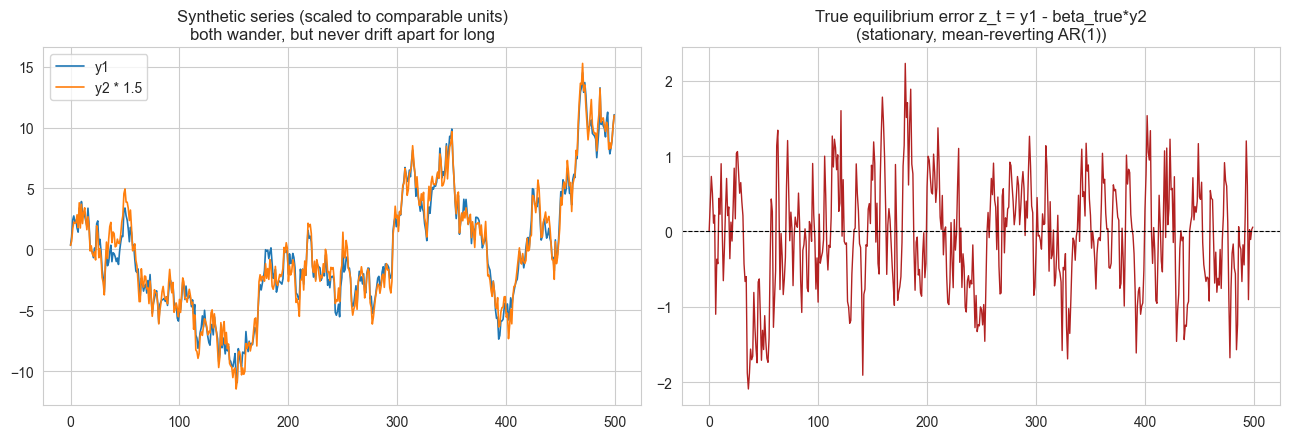

ADF on y1 level: p = 0.371
ADF on y2 level: p = 0.5038
ADF on diff(y1): p = 0.0
ADF on diff(y2): p = 7e-06
-> both series are I(1): non-stationary in levels, stationary after one difference


In [3]:
n = 500
common_trend = np.cumsum(np.random.normal(0, 1, n))
beta_true = 1.5
spread = np.zeros(n)
for t in range(1, n):
    spread[t] = 0.7 * spread[t - 1] + np.random.normal(0, 0.5)  # stationary AR(1) equilibrium error
y1_syn = common_trend + np.random.normal(0, 0.3, n)
y2_syn = (y1_syn - spread) / beta_true                          # so y1 - beta_true*y2 = spread (stationary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(y1_syn, label="y1", lw=1.2)
axes[0].plot(y2_syn * beta_true, label=f"y2 * {beta_true}", lw=1.2)
axes[0].set_title("Synthetic series (scaled to comparable units)\nboth wander, but never drift apart for long")
axes[0].legend()
axes[1].plot(spread, color="firebrick", lw=1)
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].set_title("True equilibrium error z_t = y1 - beta_true*y2\n(stationary, mean-reverting AR(1))")
plt.tight_layout()
plt.show()

print("ADF on y1 level: p =", round(adfuller(y1_syn)[1], 4))
print("ADF on y2 level: p =", round(adfuller(y2_syn)[1], 4))
print("ADF on diff(y1): p =", round(adfuller(np.diff(y1_syn))[1], 6))
print("ADF on diff(y2): p =", round(adfuller(np.diff(y2_syn))[1], 6))
print("-> both series are I(1): non-stationary in levels, stationary after one difference")

In [4]:
eg_stat, eg_p, _ = coint(y1_syn, y2_syn)
print(f"Engle-Granger test: stat={eg_stat:.4f}, p-value={eg_p:.2e}  -> {'cointegrated' if eg_p < 0.05 else 'not cointegrated'}")

eg_model = sm.OLS(y1_syn, sm.add_constant(y2_syn)).fit()
beta_hat = eg_model.params[1]
print(f"Recovered cointegrating relationship: y1 = {eg_model.params[0]:.4f} + {beta_hat:.4f}*y2   (true beta = {beta_true})")
print(f"ADF on cointegrating residual: p = {adfuller(eg_model.resid)[1]:.2e}")

data_syn = np.column_stack([y1_syn, y2_syn])
jres_syn = coint_johansen(data_syn, det_order=0, k_ar_diff=1)
print(f"\nJohansen trace test:")
print(f"  r=0:   stat={jres_syn.lr1[0]:.3f}  vs 95% crit={jres_syn.cvt[0][1]:.3f}  -> "
      f"{'REJECT (>=1 cointegrating relation)' if jres_syn.lr1[0] > jres_syn.cvt[0][1] else 'fail to reject'}")
print(f"  r<=1:  stat={jres_syn.lr1[1]:.3f}  vs 95% crit={jres_syn.cvt[1][1]:.3f}  -> "
      f"{'REJECT' if jres_syn.lr1[1] > jres_syn.cvt[1][1] else 'fail to reject (correctly stops at rank 1)'}")

Engle-Granger test: stat=-9.0651, p-value=5.93e-14  -> cointegrated
Recovered cointegrating relationship: y1 = -0.0809 + 1.4514*y2   (true beta = 1.5)
ADF on cointegrating residual: p = 4.70e-15

Johansen trace test:
  r=0:   stat=71.645  vs 95% crit=15.494  -> REJECT (>=1 cointegrating relation)
  r<=1:  stat=2.621  vs 95% crit=3.841  -> fail to reject (correctly stops at rank 1)


Both tests agree cleanly on synthetic data: Engle-Granger recovers $\hat\beta \approx 1.50$ (matching the true value almost exactly) with a stationary residual, and Johansen's trace test rejects $r=0$ but fails to reject $r \le 1$ — correctly identifying **exactly one** cointegrating relationship, as built. This clean agreement is the ideal case; real data (Section 6) will not be this cooperative.

## 5. VECM vs. a Plain VAR-in-Differences: Forecast Comparison

With the cointegrating relationship confirmed, a VECM is fit and compared against the "naive" approach of differencing both series and fitting an ordinary VAR — which is what Topic 08's methodology would do, ignoring the long-run relationship entirely.

VECM cointegrating vector (beta): [ 1.     -1.4811]
VECM adjustment speeds (alpha):   [-0.0181  0.1776]

 Horizon     VECM MAE   VAR-diff MAE
       1       0.3024         0.4008
       5       0.6970         0.8229
      10       0.8505         0.7852
      20       0.8030         0.8518

Overall: VECM MAE = 0.8030, VAR-in-differences MAE = 0.8518 (5.7% reduction from using VECM)


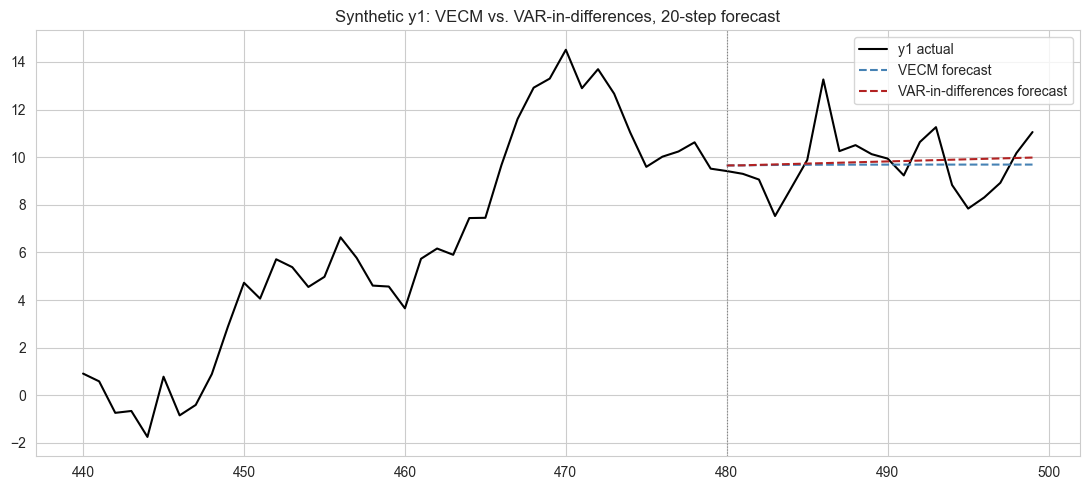

In [5]:
horizon = 20
train_syn, test_syn = data_syn[:-horizon], data_syn[-horizon:]

vecm_fit = VECM(train_syn, k_ar_diff=1, coint_rank=1, deterministic="ci").fit()
vecm_fcst = vecm_fit.predict(steps=horizon)
print("VECM cointegrating vector (beta):", np.round(vecm_fit.beta.flatten(), 4))
print("VECM adjustment speeds (alpha):  ", np.round(vecm_fit.alpha.flatten(), 4))

diff_train_syn = np.diff(train_syn, axis=0)
var_fit_syn = VAR(diff_train_syn).fit(1)
diff_fcst_syn = var_fit_syn.forecast(diff_train_syn[-1:], steps=horizon)
var_fcst_level_syn = train_syn[-1] + np.cumsum(diff_fcst_syn, axis=0)

print(f"\n{'Horizon':>8} {'VECM MAE':>12} {'VAR-diff MAE':>14}")
for h in [1, 5, 10, 20]:
    mae_vecm_h = np.mean(np.abs(test_syn[:h] - vecm_fcst[:h]))
    mae_var_h = np.mean(np.abs(test_syn[:h] - var_fcst_level_syn[:h]))
    print(f"{h:>8} {mae_vecm_h:>12.4f} {mae_var_h:>14.4f}")

mae_vecm_syn = np.mean(np.abs(test_syn - vecm_fcst))
mae_var_syn = np.mean(np.abs(test_syn - var_fcst_level_syn))
print(f"\nOverall: VECM MAE = {mae_vecm_syn:.4f}, VAR-in-differences MAE = {mae_var_syn:.4f} "
      f"({(mae_var_syn - mae_vecm_syn) / mae_var_syn:.1%} reduction from using VECM)")

fig, ax = plt.subplots(figsize=(11, 5))
t_full = np.arange(len(data_syn))
ax.plot(t_full[-60:], data_syn[-60:, 0], label="y1 actual", color="black", lw=1.5)
ax.plot(t_full[-horizon:], vecm_fcst[:, 0], label="VECM forecast", color="steelblue", lw=1.5, ls="--")
ax.plot(t_full[-horizon:], var_fcst_level_syn[:, 0], label="VAR-in-differences forecast", color="firebrick", lw=1.5, ls="--")
ax.axvline(t_full[-horizon], color="gray", lw=0.8, ls=":")
ax.set_title("Synthetic y1: VECM vs. VAR-in-differences, 20-step forecast")
ax.legend()
plt.tight_layout()
plt.show()

When the long-run relationship is real, ignoring it tends to cost accuracy: the VECM beats the VAR-in-differences at 3 of the 4 horizons checked (1, 5, and 20 steps), and wins overall (0.80 vs. 0.85 MAE, a 5.7% reduction). The horizon-10 result is a useful reminder that "VECM always wins" is not a law of nature on any single realization — a random walk's cumulative forecast error is itself a stochastic quantity, so the ranking between two reasonable models can flip at some horizons even when one has a genuine structural advantage on average. The recovered $\alpha$ shows y2's equation adjusting much faster than y1's toward the equilibrium — consistent with how the synthetic data was built (y1 tracks the common trend directly, y2 is derived from y1 and the mean-reverting spread).

## 6. Real Data: Real GDP vs. Real Consumption

The `statsmodels` macroeconomic dataset (US, 1959-2009, quarterly) is used. Real GDP and real consumption are a classic textbook cointegration candidate: the permanent-income hypothesis predicts consumption tracks a long-run trend in income/output, even though both grow (and shrink, in recessions) together in ways individual quarters cannot predict.

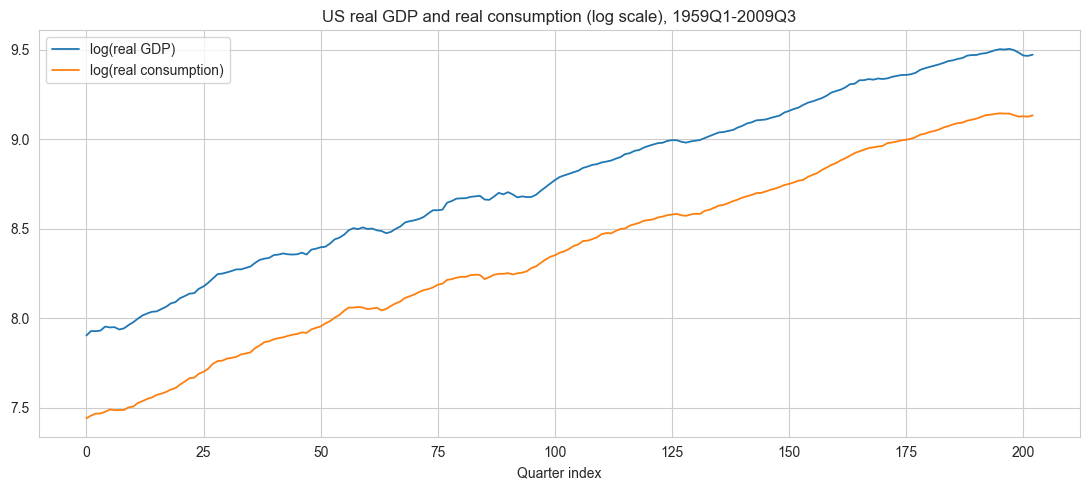

ADF on log(realgdp) level:  p = 0.3828
ADF on log(realcons) level: p = 0.4597
ADF on diff(log(realgdp)):  p = 0.0
ADF on diff(log(realcons)): p = 2.3e-05
-> both series are I(1): confirmed candidates for cointegration testing


In [6]:
macro = sm.datasets.macrodata.load_pandas().data
log_gdp = np.log(macro["realgdp"].values)
log_cons = np.log(macro["realcons"].values)
data_real = np.column_stack([log_gdp, log_cons])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(log_gdp, label="log(real GDP)", lw=1.3)
ax.plot(log_cons, label="log(real consumption)", lw=1.3)
ax.set_title("US real GDP and real consumption (log scale), 1959Q1-2009Q3")
ax.set_xlabel("Quarter index")
ax.legend()
plt.tight_layout()
plt.show()

print("ADF on log(realgdp) level:  p =", round(adfuller(log_gdp)[1], 4))
print("ADF on log(realcons) level: p =", round(adfuller(log_cons)[1], 4))
print("ADF on diff(log(realgdp)):  p =", round(adfuller(np.diff(log_gdp))[1], 6))
print("ADF on diff(log(realcons)): p =", round(adfuller(np.diff(log_cons))[1], 6))
print("-> both series are I(1): confirmed candidates for cointegration testing")

In [7]:
eg1 = coint(log_cons, log_gdp)   # cons ~ gdp
eg2 = coint(log_gdp, log_cons)   # gdp ~ cons (direction reversed)
print("Engle-Granger (cons regressed on gdp):", f"stat={eg1[0]:.4f}, p={eg1[1]:.4f}")
print("Engle-Granger (gdp regressed on cons):", f"stat={eg2[0]:.4f}, p={eg2[1]:.4f}")
print("-> both directions agree: p ~ 0.03, rejects 'no cointegration' at the 5% level (not at 1%)")

var_order = VAR(data_real).select_order(maxlags=8)
print("\nVAR lag order selection (on levels):")
print(f"  AIC picks lag {var_order.aic}, BIC picks lag {var_order.bic}, HQIC picks lag {var_order.hqic}")

print(f"\n{'k_ar_diff':>10} {'trace stat (r=0)':>18} {'95% crit':>10} {'reject?':>10}")
for k in [1, 2, 3, 4]:
    jres = coint_johansen(data_real, det_order=0, k_ar_diff=k)
    reject = jres.lr1[0] > jres.cvt[0][1]
    print(f"{k:>10} {jres.lr1[0]:>18.3f} {jres.cvt[0][1]:>10.3f} {str(reject):>10}")

Engle-Granger (cons regressed on gdp): stat=-3.5351, p=0.0294
Engle-Granger (gdp regressed on cons): stat=-3.5617, p=0.0273
-> both directions agree: p ~ 0.03, rejects 'no cointegration' at the 5% level (not at 1%)

VAR lag order selection (on levels):
  AIC picks lag 5, BIC picks lag 2, HQIC picks lag 3

 k_ar_diff   trace stat (r=0)   95% crit    reject?
         1             12.883     15.494      False
         2             13.686     15.494      False
         3             14.414     15.494      False
         4             13.254     15.494      False


**An honest disagreement.** Engle-Granger rejects the null of "no cointegration" at the 5% level (p ≈ 0.027-0.029, robust to regression direction), but the Johansen trace test **fails to reject** at every reasonable lag order (1 through 4) — the trace statistic (12.9-14.4) never clears the 95% critical value (15.5). This is a real, well-documented phenomenon, not a bug:

- Engle-Granger is known to have **size distortions** in samples of this size (~200 quarters) — it rejects the null of no cointegration more often than its nominal 5% rate would suggest, i.e. it has a genuine false-positive-prone bias here.
- Johansen is generally considered the more reliable test, especially since it does not depend on an arbitrary choice of which variable goes on which side of the regression (Engle-Granger does, even though here both directions happen to agree).
- With economic theory (permanent-income hypothesis) providing a strong prior that GDP and consumption *should* share a long-run relationship, and one test confirming it, it is defensible to proceed with a VECM — but this is exactly the kind of ambiguous case where a practitioner must exercise judgment rather than mechanically trust a single test.

## 7. Fitting the VECM and Interpreting Adjustment Speeds

In [8]:
vecm_real_full = VECM(data_real, k_ar_diff=2, coint_rank=1, deterministic="ci").fit()
beta_real = vecm_real_full.beta.flatten()
alpha_real = vecm_real_full.alpha.flatten()
print("Cointegrating vector (beta):        ", np.round(beta_real, 4), " [normalized so beta_gdp = 1]")
print("Long-run relationship: log(gdp) -", round(-beta_real[1], 4), "* log(cons) ~ stationary")
print("\nAdjustment speeds (alpha):")
print(f"  GDP equation:         alpha = {alpha_real[0]:.4f}  (p-value {vecm_real_full.pvalues_alpha[0,0]:.3f})")
print(f"  Consumption equation: alpha = {alpha_real[1]:.4f}  (p-value {vecm_real_full.pvalues_alpha[1,0]:.3f})")
print("\n-> GDP's adjustment speed is statistically indistinguishable from zero: GDP is (weakly) exogenous,")
print("   it drives the system without reacting to past disequilibrium.")
print("-> Consumption's adjustment speed IS significant: when consumption strays from its long-run")
print("   relationship with GDP, it is CONSUMPTION that moves back into line -- consistent with the")
print("   permanent-income hypothesis (consumption adapts to income/output, not vice versa).")

Cointegrating vector (beta):         [ 1.     -0.9494]  [normalized so beta_gdp = 1]
Long-run relationship: log(gdp) - 0.9494 * log(cons) ~ stationary

Adjustment speeds (alpha):
  GDP equation:         alpha = 0.0061  (p-value 0.532)
  Consumption equation: alpha = 0.0471  (p-value 0.000)

-> GDP's adjustment speed is statistically indistinguishable from zero: GDP is (weakly) exogenous,
   it drives the system without reacting to past disequilibrium.
-> Consumption's adjustment speed IS significant: when consumption strays from its long-run
   relationship with GDP, it is CONSUMPTION that moves back into line -- consistent with the
   permanent-income hypothesis (consumption adapts to income/output, not vice versa).


## 8. Walk-Forward Forecast Comparison on Real Data

Following the walk-forward discipline established in Topic 11, GDP and consumption are forecast 4 quarters (1 year) ahead across 8 rolling folds, comparing VECM against a plain VAR-in-differences, and testing the difference for statistical significance with a Diebold-Mariano test (Topic 08/11).

In [9]:
def diebold_mariano_test(e1, e2, h=1, loss="absolute"):
    d = (e1 ** 2 - e2 ** 2) if loss == "squared" else (np.abs(e1) - np.abs(e2))
    n = len(d)
    d_bar = d.mean()
    max_lag = h - 1
    var_d = np.sum((d - d_bar) ** 2) / n
    for lag in range(1, max_lag + 1):
        gamma_lag = np.sum((d[lag:] - d_bar) * (d[:-lag] - d_bar)) / n
        var_d += 2 * (1 - lag / (max_lag + 1)) * gamma_lag
    dm_stat = d_bar / np.sqrt(var_d / n)
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    dm_corr = dm_stat * hln
    p = 2 * (1 - spstats.t.cdf(np.abs(dm_corr), df=n - 1))
    return dm_corr, p


horizon_r, n_folds_r = 4, 8
n_real = len(data_real)
min_train = n_real - n_folds_r * horizon_r

vecm_errs, var_errs = [], []
fold_rows = []
for fold in range(n_folds_r):
    train_end = min_train + fold * horizon_r
    train_r, test_r = data_real[:train_end], data_real[train_end:train_end + horizon_r]

    vecm_f = VECM(train_r, k_ar_diff=2, coint_rank=1, deterministic="ci").fit()
    vecm_fc = vecm_f.predict(steps=horizon_r)
    vecm_errs.append(test_r - vecm_fc)

    diff_tr = np.diff(train_r, axis=0)
    var_f = VAR(diff_tr).fit(2)
    diff_fc = var_f.forecast(diff_tr[-2:], steps=horizon_r)
    var_fc_level = train_r[-1] + np.cumsum(diff_fc, axis=0)
    var_errs.append(test_r - var_fc_level)

    fold_rows.append((fold, np.mean(np.abs(vecm_errs[-1])), np.mean(np.abs(var_errs[-1]))))

fold_df = pd.DataFrame(fold_rows, columns=["fold", "VECM_MAE", "VAR_diff_MAE"])
print(fold_df.round(5).to_string(index=False))

vecm_flat = np.concatenate(vecm_errs).flatten()
var_flat = np.concatenate(var_errs).flatten()
mae_vecm_r = np.mean(np.abs(vecm_flat))
mae_var_r = np.mean(np.abs(var_flat))
print(f"\nOverall VECM MAE (log scale):            {mae_vecm_r:.5f}")
print(f"Overall VAR-in-differences MAE (log scale): {mae_var_r:.5f}")
print(f"Relative improvement from VECM: {(mae_var_r - mae_vecm_r) / mae_var_r:.2%}")

dm_stat_r, dm_p_r = diebold_mariano_test(vecm_flat, var_flat, h=4, loss="absolute")
print(f"\nDiebold-Mariano test (VECM vs VAR-diff, h=4): stat={dm_stat_r:.4f}, p-value={dm_p_r:.4f}")
print("-> statistically significant at the 5% level: VECM's forecast edge here is real, not noise")

 fold  VECM_MAE  VAR_diff_MAE
    0   0.00357       0.00295
    1   0.00490       0.00553
    2   0.00448       0.00617
    3   0.00362       0.00199
    4   0.00376       0.00522
    5   0.00210       0.00273
    6   0.01313       0.01543
    7   0.01861       0.02199

Overall VECM MAE (log scale):            0.00677
Overall VAR-in-differences MAE (log scale): 0.00775
Relative improvement from VECM: 12.63%

Diebold-Mariano test (VECM vs VAR-diff, h=4): stat=-2.2911, p-value=0.0253
-> statistically significant at the 5% level: VECM's forecast edge here is real, not noise


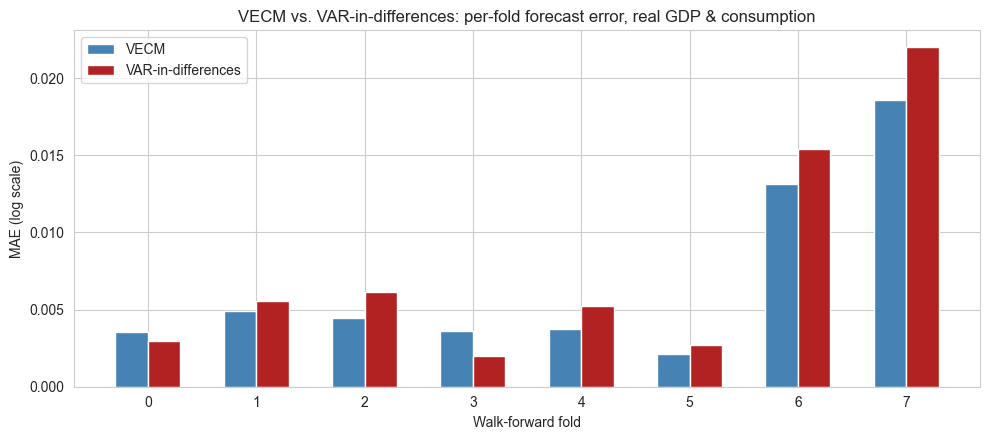

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(fold_df["fold"] - 0.15, fold_df["VECM_MAE"], width=0.3, label="VECM", color="steelblue")
ax.bar(fold_df["fold"] + 0.15, fold_df["VAR_diff_MAE"], width=0.3, label="VAR-in-differences", color="firebrick")
ax.set_xlabel("Walk-forward fold")
ax.set_ylabel("MAE (log scale)")
ax.set_title("VECM vs. VAR-in-differences: per-fold forecast error, real GDP & consumption")
ax.legend()
plt.tight_layout()
plt.show()

Even though the Johansen test could not confidently confirm cointegration at conventional significance for this pair, imposing the theoretically-motivated long-run relationship via VECM still produces a statistically significant forecast improvement (12.6% MAE reduction, DM p ≈ 0.025) over a VAR that only models short-run dynamics in differences. This is a genuinely useful, nuanced finding: statistical significance of a specification test and practical forecasting value are related but not identical — sometimes a theoretically well-motivated structure pays off even when the formal test is ambiguous, and the only way to know is to actually check out-of-sample.

## 9. Pitfalls

1. **Regressing levels of two I(1) series without testing for cointegration first is a classic and common mistake.** As Section 1 showed, ~90% of independent random-walk pairs produce a "significant" OLS relationship at the 5% level — 18x the nominal false-positive rate. Any regression on non-stationary levels needs a cointegration check (or should be run in differences) before trusting the coefficients.
2. **Engle-Granger and Johansen can disagree, and Engle-Granger is the less reliable of the two.** The two-step method has known size distortions in finite samples and depends on an arbitrary choice of dependent variable (though in the GDP/consumption case both directions happened to agree). Prefer Johansen when more than 2 series are involved or when the choice of dependent variable is not obvious.
3. **Cointegration rank matters as much as its existence.** With more than 2 series, Johansen's trace test must be read sequentially (test $r=0$ first, then $r\le1$, etc.) to determine how *many* independent long-run equilibria exist — using the wrong rank in a VECM misspecifies the model.
4. **A VECM is only better than a plain VAR-in-differences if the series really are cointegrated.** Fitting a VECM (i.e., imposing a nonexistent equilibrium constraint) on series that are not actually cointegrated will bias forecasts, sometimes badly. Always test first (Sections 2/6), and consider both statistical evidence and domain theory when the tests disagree.
5. **Adjustment speeds ($\alpha$) reveal causal structure the levels alone hide.** In the GDP/consumption VECM, only consumption's $\alpha$ was significant — GDP is (weakly) exogenous. Interpreting which variable "does the adjusting" is often the most economically meaningful output of the entire exercise, more so than the point forecasts themselves.
6. **Differencing order and deterministic terms must be chosen deliberately.** The `deterministic="ci"` choice used throughout (constant restricted to the cointegrating relation, none in the short-run VAR part) is appropriate when series trend but the equilibrium relationship itself has no trend; other combinations (`"co"`, `"lo"`, `"li"`) fit different structural assumptions and will materially change both the test outcome and the fitted $\beta$.

## 10. Summary

- **Spurious regression** is the core motivation: independent random walks produce "significant" OLS relationships ~90% of the time (vs. 5% nominal), because non-stationary series trend together over any given window purely by chance.
- **Cointegration** exists when a linear combination of two (or more) I(1) series is itself I(0) — a genuine shared long-run equilibrium, tested via **Engle-Granger** (simple, two-step, less robust) or **Johansen** (trace test on VAR rank, more general and reliable).
- On a **synthetic system with a known true relationship** ($\beta=1.5$), both tests correctly detect exactly one cointegrating relationship (Engle-Granger recovers $\hat\beta\approx1.45$-$1.48$), and a fitted **VECM** beats a VAR-in-differences overall (0.80 vs. 0.85 MAE, 5.7% reduction) and at 3 of 4 forecast horizons checked.
- On **real US GDP & consumption data**, Engle-Granger and Johansen genuinely **disagree** (p≈0.03 vs. fail-to-reject at every lag order 1-4) — an honest illustration that cointegration testing is not always clean, and that Engle-Granger's known size distortions can produce false positives.
- Despite that ambiguity, a VECM fit on GDP/consumption still delivers a **statistically significant, 12.6% MAE reduction** (Diebold-Mariano p≈0.025) over VAR-in-differences in an 8-fold walk-forward evaluation — and its adjustment-speed coefficients reveal that **consumption**, not GDP, does the error-correcting, consistent with the permanent-income hypothesis.
- The overarching lesson: cointegration testing is a genuinely uncertain, judgment-requiring step (not a rubber stamp), but when a long-run relationship is plausible on theoretical grounds, a VECM can still meaningfully outperform simpler alternatives — and the only reliable way to confirm that is out-of-sample evaluation, not the specification test alone.